In [1]:
from cats.cdataframe   import CDataFrame   # tool for extracting data from root files (made by your local developer, Mason Buchanan)

Welcome to JupyROOT 6.28/10


In [2]:
import matplotlib.pyplot as plt    # Matplotlib is the most common plotting package for Python

#The next line is a 'magic' command (indicated by the '%'). These tend to do useful meta things.
%matplotlib inline
#This one makes plots show up in your notebooks. (Note that you can't put comments after it on the same line!)

import pandas as pd                # Some additional data-handling tools
import numpy as np                 # "Numerical python". You need this to process data efficiently
import glob                        # Might be useful for getting files
import cdms
from rawio.IO import *             # Useful for reading binary files which contain raw pulses
import os,sys

CDMS = os.environ["CDMS"] # set in ~/.bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","rainbow.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup
import detectorLayout

In [3]:
DMCfiles = np.sort(glob.glob('/scratch/user/perry5334/samples/DMC_SNOLAB_HV/HV100mm_1keV_100V_FastDMC/DMCOutput/HV100mm_1keV_100V_00241223_000000.root'))

In [4]:
g4dmcHits = CDataFrame('G4SimDir/g4dmcHits', DMCfiles)
X = g4dmcHits.AsNumpy(['X'])['X']*1e3
Y = g4dmcHits.AsNumpy(['Y'])['Y']*1e3
Z = g4dmcHits.AsNumpy(['Z'])['Z']*1e3

In [5]:
peakBins = {chan: None for chan in range(12)}

g4dmcTES = CDataFrame('G4SimDir/g4dmcTES', DMCfiles)
T0       = g4dmcTES.Filter(f'EventNum == 0').AsNumpy(['T0'])['T0'][0]
BinWidth = g4dmcTES.Filter(f'EventNum == 0').AsNumpy(['BinWidth'])['BinWidth'][0]
TimeBins = np.arange(T0, T0 + BinWidth * 32768, BinWidth) * 1e-3 # ns -> us

for chan in range(12):
    Trace = g4dmcTES.Filter(f'ChanNum == {chan}').AsNumpy(['Trace'])['Trace']
    Trace = np.array([max(i) - i for i in Trace]) # flip traces right-side up
    peakBins[chan] = np.array([TimeBins[np.argmax(i)] for i in Trace])

In [12]:
g4dmcTES.Filter(f'ChanNum == {chan}').AsNumpy(['T0'])['T0']

ndarray([-26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -26880000., -26880000., -26880000.,
         -26880000., -26880000., -

In [7]:
geomFile = np.sort(glob.glob('/scratch/user/perry5334/samples/DMC_SNOLAB_HV/HV100mm_30eV_0V_tracks/DMCOutput/DMCOutput_51241116_000000.root'))[0]

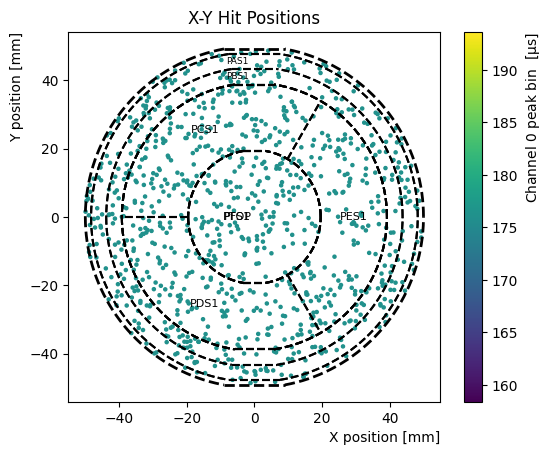

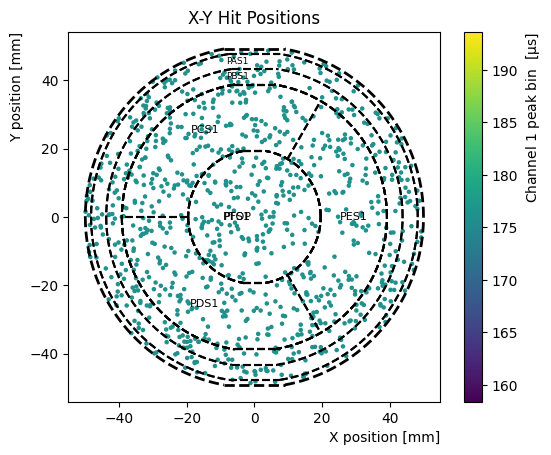

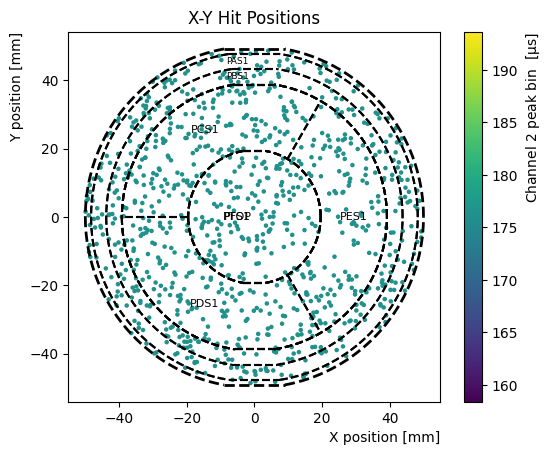

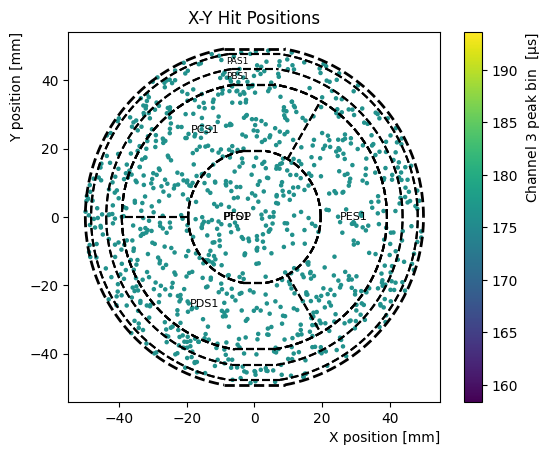

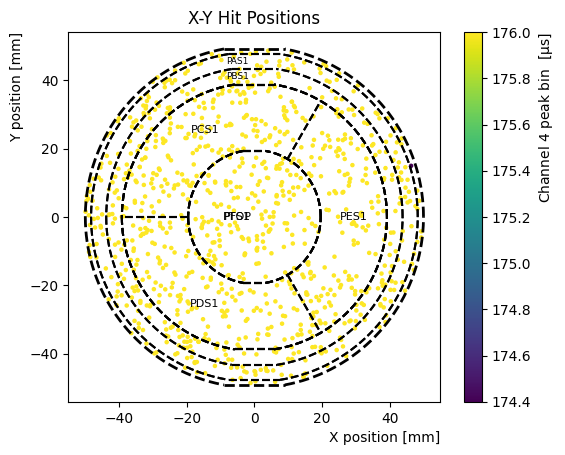

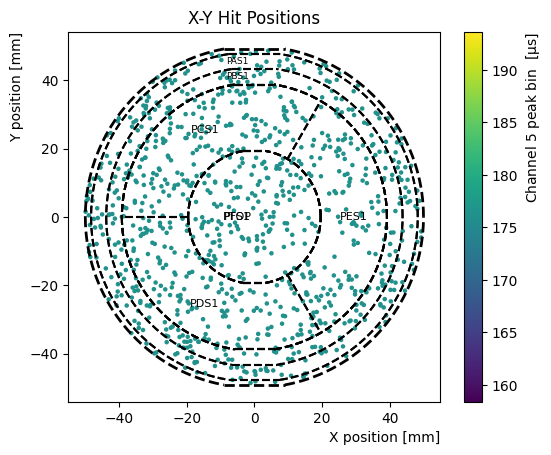

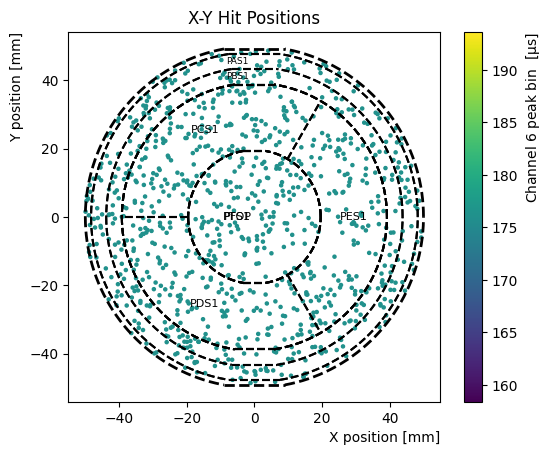

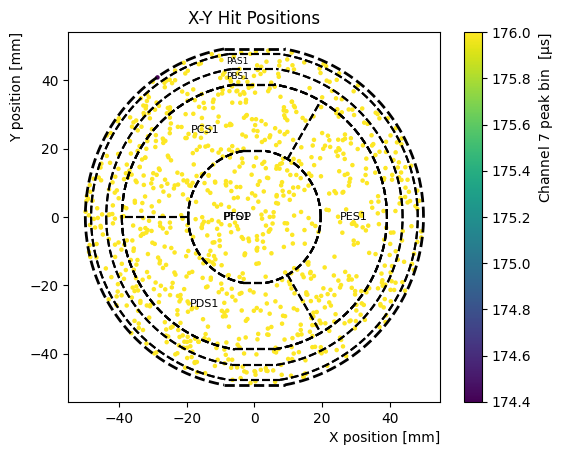

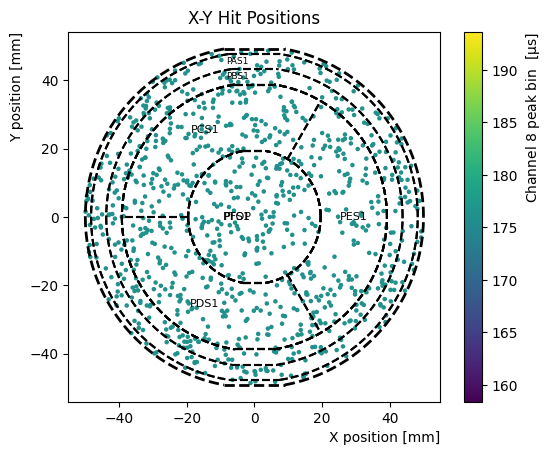

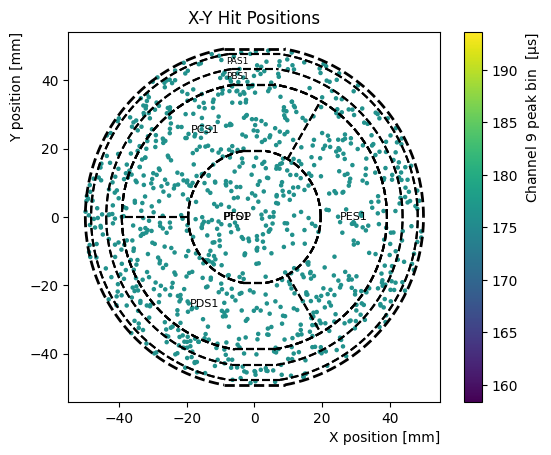

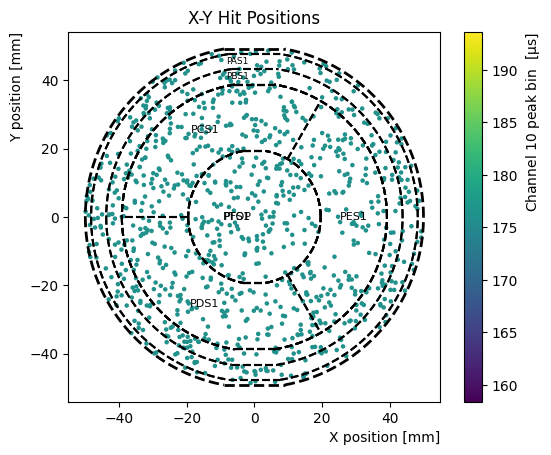

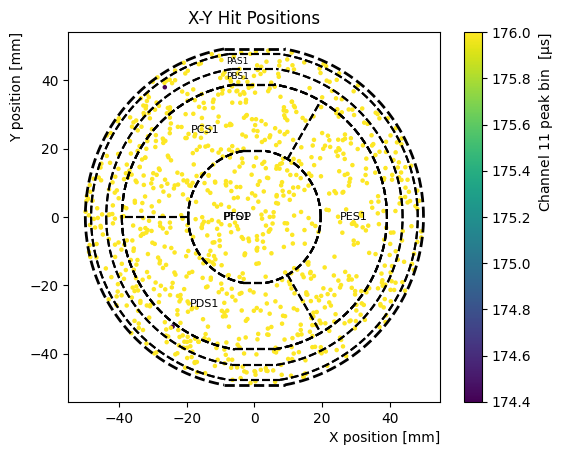

In [10]:
for chan in range(12):

    plt.figure(figsize=(5*1.2,4*1.2), dpi=100)

    plt.scatter(X, Y, c=peakBins[chan], cmap='viridis', s = 5)
    detectorLayout.drawDetOutline(geomFile, color='black', lw = 2, ls = '--')
    detectorLayout.drawChanOutline(geomFile, color='black', side=1, chantype=1, labels=1, lw = 1.5, ls = '--')

    plt.xlabel("X position [mm]")
    plt.ylabel("Y position [mm]")
    plt.title(f"X-Y Hit Positions")
    plt.colorbar(label = "Channel " + str(chan) + ' peak bin ' + r' [$\mathrm{\mu s}$]')